# Part A: Conditional DCGAN on CIFAR10

One sentence stating the goal: build a class-conditional DCGAN that generates 1000 CIFAR10 images (100 per class), as a second generative approach alongside the CVAE for comparison.

## 1. Imports and Setup

In [1]:
!pip install -U "datasets>=4.8.4"

In [2]:
# Import tensorflow/keras, numpy, matplotlib; set random seed for reproducibility.
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
import torch.nn.functional as F
from torchvision.transforms import functional as F_t
from torchvision.datasets import CIFAR10
import datasets 
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
print(f'running on {device}')

running on cuda


In [ ]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

## 2. Approach

One sentence describing why a class-conditional DCGAN is a suitable second approach here, noting unconditional GANs on all 10 CIFAR10 classes at once are notably harder to converge than single-class, which is why conditioning is treated as part of the baseline rather than an experiment.

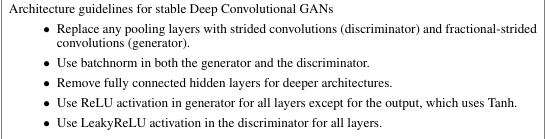

## 3. Preprocessing

### 3.1 Normalize Pixel Values

One sentence noting we're scaling pixels to [-1, 1] rather than [0, 1] here, since the generator's output layer uses tanh (not sigmoid like the VAE decoder).

In [3]:
image_data = datasets.load_dataset('uoft-cs/cifar10').with_format('torch')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [4]:
# Cast images to float32 and normalize pixel values to [-1, 1] to match the generator's tanh output range.
train_data = image_data['train'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=2)
test_data = image_data['test'].map(lambda x: {'img': x/127.5 - 1}, input_columns=['img'], batched=True, batch_size=500, num_proc=2)


In [5]:
# one batch
sample_batch = torch.tensor(test_data.select(range(64)).with_format(None)['img'])
print(f'range: {sample_batch.min()} to {sample_batch.max()}')

range: -1.0 to 1.0


### 3.2 Encode Labels

One sentence noting we're one-hot encoding the 10 class labels so they can be concatenated into the generator and discriminator as the conditioning signal, same approach as the CVAE.

In [6]:
# One-hot encode the 10 class labels for use as the conditioning input.
def one_hot_encode(batch):
    labels = []
    for n in batch:
        r = [0]*10
        r[n.item()] = 1
        labels.append(r)
    return {'label': labels}
train_data = train_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=4)
test_data = test_data.map(one_hot_encode, input_columns=['label'], batched=True, batch_size=500, num_proc=4)
test_loader = DataLoader(test_data, shuffle=True, batch_size=1)

### 3.3 Train/Validation Split

One sentence noting we're carving a validation set out of the 50k training images, used for the discriminator-accuracy diagnostic and to keep this preprocessing identical to the CVAE baseline's.

In [7]:
# Shuffle the training set and split off a validation set (e.g. 45k/5k).
val_data = train_data.shuffle(seed=42).select(range(5000))
train_data = train_data.shuffle(seed=42).select(range(45000))
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)

## 4. Build the Conditional Generator

### 4.1 What It Does

One sentence explaining that a noise vector and the one-hot label are concatenated, dense-expanded, and upsampled via transposed convs into a 32x32x3 image — followed by a diagram of this layer flow.

According to the DCGAN paper, 
* One fully-connected layer -> convolutional upsampling to 3x32x32 image
* ReLU applied to all layers besides the last layer
* BatchNorm applied to all layers besides the last layer
* Tanh activation applied to last layer

In [8]:
# Diagram: generator layer flow — noise z + label -> concat -> dense expand -> reshape -> transposed conv stack (BatchNorm + ReLU) -> tanh output.
class generator(nn.Module):
    def __init__(self, noise_dim):
        super().__init__()
        self.proj = nn.Linear(noise_dim + 10, 256*4*4)
        self.bn_proj = nn.BatchNorm1d(256*4*4)
        self.convT1 = nn.ConvTranspose2d(256, 128, 4, 2, 1) # 4x4 -> 8x8
        self.bn1 = nn.BatchNorm2d(128)

        self.convT2 = nn.ConvTranspose2d(128, 64, 4, 2, 1) # 8x8 -> 16x16
        self.bn2 = nn.BatchNorm2d(64)

        self.convT3 = nn.ConvTranspose2d(64, 3, 4, 2, 1) # 16x16 -> 32x32

        #activations
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()



    def forward(self, noise, label):
        x = torch.concat((noise, label), dim=1)
        x = self.relu(self.bn_proj(self.proj(x)))
        x = x.reshape(-1, 256, 4, 4)
        
        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.tanh(self.convT3(x))
        return x

### 4.2 Implementation

No optimization tricks here (no spectral norm, no custom learning rate) — this is a plain conditional generator; tuning is reserved for `gan_improvement.ipynb`.

torch.Size([64, 3, 32, 32])
range: -0.9999271631240845 ,0.9994968175888062


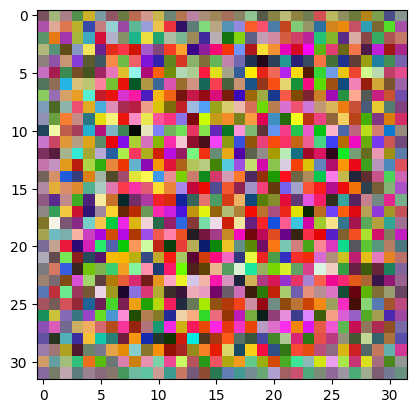

In [9]:
# Build the generator: concatenate noise vector with label, dense-expand, then transposed convs (strided, BatchNorm, ReLU) back to 32x32x3, tanh output.
gen = generator(128)
noise = torch.randn((64, 128))
label = next(iter(train_loader))['label']
test_gen_output = gen(noise, label)
print(test_gen_output.shape)
print(f'range: {test_gen_output.min().item()} ,{test_gen_output.max().item()}')
plt.imshow(F_t.to_pil_image(
    ((test_gen_output[0]+1)*127.5).to(torch.uint8)
))

## 5. Build the Conditional Discriminator

### 5.1 What It Does

One sentence explaining that the image and the one-hot label (broadcast to a spatial map) are concatenated as input, then strided convs reduce it to a single real/fake logit — followed by a diagram of this layer flow.

according to dcgan paper:
* only one fully-connected layer to convert flattened final convolutional layer into a singular sigmoid output
* batchnorm applied to all layers except the input layer
* leakyrelu used in all discriminator layeres besides the last sigmoid output
* exclusion of pooling layers

In [10]:
train_data['label'][0].reshape(1, 10, 1, 1).expand(1, 10, 32, 32)
class discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 64, 3, 2, 1) # 32x32 -> 16x16

        self.conv2 = nn.Conv2d(64, 128, 3, 2, 1) # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, 3, 2, 1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(256)

        self.fc_out = nn.Linear(256*4*4, 1) 
        # activations
        
        self.leakyrelu = nn.LeakyReLU(0.2)
        self.sigmoid = nn.Sigmoid()

        # reg
        self.dropout2d = nn.Dropout2d(0.3)
        
    def forward(self, x, label):
        batch_size = x.size(0)
        label = label.reshape(batch_size, 10, 1, 1).expand(batch_size, 10, 32, 32)
        x = torch.concat((x, label), dim=1)
        x = self.leakyrelu(self.conv1(x))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn2(self.conv2(x)))
        x = self.dropout2d(x)
        x = self.leakyrelu(self.bn3(self.conv3(x)))
        x = self.dropout2d(x)
        x = x.flatten(start_dim=1)
        x = self.sigmoid(self.fc_out(x))
        return x

# i made this just to visualise the input channels:
# fig, ax = plt.subplots(1, 3)
# for i in range(3):
#     im = d(sample['img'], sample['label'])[0][i]
#     ax[i].imshow(F_t.to_pil_image(((im+1)*127.5).to(torch.uint8)), vmin=0, vmax=255)  
# plt.show()   
# fig, ax = plt.subplots(1, 10)
# for i in range(10):
#     im = d(sample['img'], sample['label'])[0][i+3]
#     ax[i].imshow(F_t.to_pil_image(((im+1)*127.5).to(torch.uint8)), vmin=0, vmax=255)  

# plt.show()

In [11]:
# Diagram: discriminator layer flow — image + label map -> concat -> strided conv stack (LeakyReLU) -> flatten -> dense -> real/fake logit.
d = discriminator()
sample = next(iter(train_loader))
test_disc_output = d(sample['img'], sample['label'])
print(test_disc_output.shape)
print(test_disc_output.T)

torch.Size([64, 1])
tensor([[0.4841, 0.3212, 0.7073, 0.3245, 0.4518, 0.3784, 0.5662, 0.3685, 0.4686,
         0.6135, 0.2523, 0.4925, 0.4745, 0.4535, 0.3778, 0.5071, 0.6201, 0.2779,
         0.6644, 0.2505, 0.2855, 0.3653, 0.4255, 0.4844, 0.4656, 0.4627, 0.4219,
         0.5142, 0.4830, 0.4060, 0.5123, 0.5489, 0.3866, 0.4419, 0.3619, 0.3904,
         0.3547, 0.5334, 0.4138, 0.4921, 0.5683, 0.5106, 0.5186, 0.6124, 0.5163,
         0.3837, 0.4272, 0.5460, 0.5236, 0.4852, 0.4761, 0.6913, 0.3531, 0.4157,
         0.3996, 0.3888, 0.3678, 0.3663, 0.4914, 0.5055, 0.4335, 0.5117, 0.5316,
         0.2737]], grad_fn=<PermuteBackward0>)


### 5.2 Implementation

Plain conditional discriminator — no spectral normalization, no label smoothing baked in here; those are experiments, not baseline defaults.

In [12]:
# Build the discriminator: concatenate image with a broadcast label map, strided conv stack (LeakyReLU, dropout), flatten, dense to a single logit.

## 6. Define the GAN Training Step

### 6.1 Loss Formulation

One sentence explaining the discriminator is trained to separate real from generated images (binary cross-entropy, hard 0/1 targets — no label smoothing in the baseline) while the generator is trained to fool it, and why both losses are tracked separately rather than combined into one number.

### 6.2 Architecture Pseudocode

```
train_step(images, labels):
    noise = random_normal(batch_size, latent_dim)

    with gradient_tape() as disc_tape:
        fake_images = generator(noise, labels)
        real_logits = discriminator(images, labels)
        fake_logits = discriminator(fake_images, labels)
        disc_loss = bce(ones_like(real_logits), real_logits) + bce(zeros_like(fake_logits), fake_logits)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.weights)
    disc_optimizer.apply_gradients(disc_gradients)

    noise = random_normal(batch_size, latent_dim)
    with gradient_tape() as gen_tape:
        fake_images = generator(noise, labels)
        fake_logits = discriminator(fake_images, labels)
        gen_loss = bce(ones_like(fake_logits), fake_logits)
    gen_gradients = gen_tape.gradient(gen_loss, generator.weights)
    gen_optimizer.apply_gradients(gen_gradients)

    return gen_loss, disc_loss
```

### 6.3 Implementation

Plain BCE loss, hard targets, one Adam optimizer per network at the same default learning rate — no TTUR, no label smoothing (those are Experiments 1 and 2 in `gan_improvement.ipynb`).

* adam optimiser beta_1 set to 0.5 due to previous empirical evidence showing its effectiveness. we attribute its effectiveness to a lower beta_1 allowing the two models adapt to the adversarial environment quicker due to a lower 'momentum influence'.

In [ ]:
# Define the GAN keras.Model subclass with a custom train_step implementing the alternating generator/discriminator updates above.
noise_dim = 64

G = generator(128).to(device)

D = discriminator().to(device)

g_lr = 0.0002
d_lr = 0.0002

g_optim = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optim = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion = nn.BCELoss()

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=True)

epochs = 50

def set_requires_grad(model, yesno):
    for param in model.parameters():
        param.requires_grad_(yesno)


for e in range(epochs):
    D.train()
    G.train()
    for idx, sample in enumerate(train_loader):
        img = sample['img'].to(device)
        label = sample['label'].to(device)

        batch_size = img.size(0)

        target_ones = torch.ones(batch_size).unsqueeze(1).to(device)
        target_zeros = torch.zeros(batch_size).unsqueeze(1).to(device)
        
        # generate fake image batch
        noise = torch.randn((batch_size,128)).to(device)
        generated_img = G(noise, label)
        
        # unfreeze discriminator 
        # reset discriminator optimizer accumulated gradients
        set_requires_grad(D, True)
        d_optim.zero_grad() 

        real_d_pred = D(img, label)
        real_d_loss = criterion(real_d_pred, target_ones) # predict D(x) = 1

        fake_d_pred = D(generated_img.detach(), label)
        fake_d_loss = criterion(fake_d_pred, target_zeros) # predict D(G(z)) = 0

        # d_loss = loss(real) + loss(fake)
        # backprop -> step
        d_loss = real_d_loss + fake_d_loss
        d_loss.backward()
        d_optim.step()

        # freeze discriminator
        set_requires_grad(D, False)
        # reset generator optimizer accumulated gradients
        g_optim.zero_grad()

        g_pred = D(generated_img, label) # uses the new discriminator
        g_loss = criterion(g_pred, target_ones) # predict D(G(z)) = 1
        g_loss.backward()
        g_optim.step()

        D_x = real_d_pred.mean()
        D_Gz = g_pred.mean()

    # validation
    for idx, sample in val_loader:
        #fuck 
        print('Hello')
    print(f'\tD_x: \t{D_x:.4f}')
    print(f'\tD_Gz: \t{D_Gz:.4f}')
    print(f'D Loss (real): \t{real_d_loss:.4f}')
    print(f'D Loss (fake): \t{fake_d_loss:.4f}')
    print(f'G Loss (fake): \t{g_loss:.4f}')

    break;

tensor(0.8533, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
	D_x: 	0.4746
	D_Gz: 	0.4378
D Loss (real): 	0.7847
D Loss (fake): 	0.6790
G Loss (fake): 	0.8533
tensor(0.8047, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.8208, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.8761, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.8990, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.9073, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.9705, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(1.0070, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(1.0149, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.9790, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(1.0335, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(1.0681, device='cuda:0', grad_fn=<BinaryCrossEntropyBackward0>)
tensor(1.1995, device='cuda:0', grad_fn=<BinaryCro

KeyboardInterrupt: 

In [ ]:
with torch.no_grad():
    G.eval()
    sample = next(iter(train_loader))
    img = sample['img'].to(device)
    label = sample['label'].to(device)
    noise = torch.randn((64,128)).to(device)
    generated_img = G(noise, label)



## 7. Train the Model

### 7.1 Fit and Save Best Weights

One sentence noting GANs have no single validation loss to checkpoint against (unlike the VAE), so weights are saved at a fixed final epoch after confirming training didn't visibly collapse in Section 8.

In [ ]:
# Compile and fit the GAN for a fixed number of epochs, saving the generator's weights to a .h5 checkpoint at the end.

### 7.2 Loss Curves

One sentence noting generator and discriminator loss are plotted on the same axes (not separately), since it's the balance between them — not either curve's absolute value — that indicates healthy GAN training.

In [ ]:
# Plot generator loss and discriminator loss on the same axes across training epochs.

## 8. Diagnostics

### 8.1 Fixed-Noise Progression Grid

One sentence noting the same fixed noise vector + label set is decoded every N epochs during training, producing a grid that shows the model visibly learning over time rather than just a before/after snapshot.

In [ ]:
# Generate images from a fixed noise+label batch every N epochs during training; display the saved snapshots as a progression grid.

### 8.2 Mode Collapse Quantification

One sentence noting we're computing pairwise pixel-distance (or std-dev) across a batch of same-class generated images as a numeric diversity check, rather than relying on eyeballing a sample grid for repeated images.

In [ ]:
# Generate a batch of images for one class, compute average pairwise pixel distance (or per-pixel std-dev) as a diversity score.

### 8.3 Nearest-Neighbor Check

One sentence noting we're comparing a handful of generated images against their closest real training image (by pixel distance) to check the generator is synthesizing, not memorizing, the training data.

In [ ]:
# For a few generated images, find and display the nearest real training image by pixel distance, side by side.

## 9. Generate 1000 Class-Conditioned Images

### 9.1 Sample and Generate

One sentence noting generation samples fresh noise vectors from the prior (not real images) and pairs them with a chosen class label, run through the generator only.

In [ ]:
# Sample random noise vectors, generate with each of the 10 class labels to produce 100 images per class (1000 total).

### 9.2 Save to Disk

One sentence noting all 1000 images are written to disk organized by class folder, as required for submission.

In [ ]:
# Save the generated images to disk as required for submission.

### 9.3 Preview Grid

One sentence noting we're displaying a small sample (a few per class) inline for a visual sanity check, separate from the full 1000 saved to disk.

In [ ]:
# Display a grid of sample generated images, a few per class, for visual inspection.

## 10. Evaluate Generated Image Quality

### 10.1 Eye-Test Scoring

One sentence noting we're manually scoring a sample of the saved generated images (e.g. 10 per class) as clear/marginal/nonsense, using the identical scoring criteria as the CVAE baseline so the two architectures are directly comparable later; FID is added in Section 10.5 as a quantitative complement.

In [ ]:
# Manually score a sample of generated images per class as clear / marginal / nonsense, tally results.

### 10.2 Per-Class Score Summary

One sentence noting we're tallying the eye-test scores by class into a bar chart, giving the evidence base for the discussion below.

In [ ]:
# Tally clear/marginal/nonsense counts per class, bar chart the result.

### 10.3 Discussion: Class Difficulty

One sentence noting which classes scored best/worst on the eye-test here, and whether the pattern matches or differs from the CVAE's class-difficulty findings.

### 10.4 Discussion: Color vs. Black-and-White (Prediction)

One sentence giving a reasoned prediction only (no grayscale model trained here) on whether black-and-white generation would be easier or harder for this GAN — this prediction is tested empirically in `gan_improvement.ipynb` Section 7 (Experiment 4: Color vs. Grayscale), which is the notebook to cite for the actual answer.

## 11. Baseline Conclusion

One sentence summarizing baseline GAN performance and key takeaways, plus saving the baseline weights/metrics to disk so `gan_improvement.ipynb` can load them without retraining.

In [ ]:
# Save baseline config, final losses, eye-test scores, and FID score to a small JSON file for gan_improvement.ipynb to load.

In [ ]:
# Extract InceptionV3 features for a sample of real validation images and for the 1000 generated images.

In [ ]:
# Fit a Gaussian (mean, covariance) to each feature set, compute Frechet distance between them, print the FID score.

## 11. Baseline Conclusion

One sentence summarizing baseline GAN performance and key takeaways, plus saving the baseline weights/metrics to disk so `gan_improvement.ipynb` can load them without retraining.

In [ ]:
# Save baseline config, final losses, and eye-test scores to a small JSON file for gan_improvement.ipynb to load.